In [3]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_pure_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 8
e0 = 0.4
xI0 = 1.0
dist = 9 # 9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],     
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}



def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))*anneal_state['S']
        except Exception:
            pass
    return out



def prior_transform(u):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [4]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/stage1/anneal'


In [5]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [6]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [7]:
sampler.init_cov_list

[array([[ 0.01572507,  0.014258  , -0.01070597, -0.01417223,  0.00203919],
        [ 0.014258  ,  0.07106442, -0.00423203,  0.00139184,  0.0022353 ],
        [-0.01070597, -0.00423203,  0.09782977, -0.00086734,  0.00207623],
        [-0.01417223,  0.00139184, -0.00086734,  0.06101257,  0.00125546],
        [ 0.00203919,  0.0022353 ,  0.00207623,  0.00125546,  0.091388  ]])]

In [8]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [9]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.26315645,  0.03596842,  0.93277761,  0.95087384,  0.90024707],
        [ 0.44485039,  0.22442601,  0.67675754,  0.37995207,  1.27487837],
        [ 0.32823316, -0.16796229,  0.44119823,  0.86546941,  0.4044767 ],
        ...,
        [ 0.43539666,  0.13190994,  0.80912501,  0.69821092,  0.94644669],
        [ 0.22668817,  0.06487691,  1.01547897,  1.12279416,  0.84200276],
        [ 0.44202083,  0.17792795,  0.84100865,  0.64146383,  0.94069413]])]

In [10]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([489.4538697,        -inf,        -inf, ..., 451.9093192,
               -inf, 460.4387938])]

In [11]:
sampler.now_covariances

[array([[ 0.00761305,  0.00420914, -0.00361865, -0.01692124,  0.00231252],
        [ 0.00420914,  0.00372702, -0.00129914, -0.00782643,  0.0005933 ],
        [-0.00361865, -0.00129914,  0.00589198,  0.00698788, -0.00255114],
        [-0.01692124, -0.00782643,  0.00698788,  0.04113166, -0.00544941],
        [ 0.00231252,  0.0005933 , -0.00255114, -0.00544941,  0.00152794]])]

In [12]:
np.argmax(logden_list)

51556

In [13]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.81762742, 0.87172917, 0.92974298, 9.04845282, 0.47697003]])

In [14]:
log_density(maxld_pt1)

array([49.75732882])

In [15]:
log_density([param_true])

array([62.32136975])

In [16]:
param_ranges = [(5.5,6.3),
                (0.8,1.3),
                (0.3,0.99),
                (7.0,10.0),
                (0.2,0.5),
                ]
param_ranges

[(5.5, 6.3), (0.8, 1.3), (0.3, 0.99), (7.0, 10.0), (0.2, 0.5)]

In [17]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 8, 0.4]

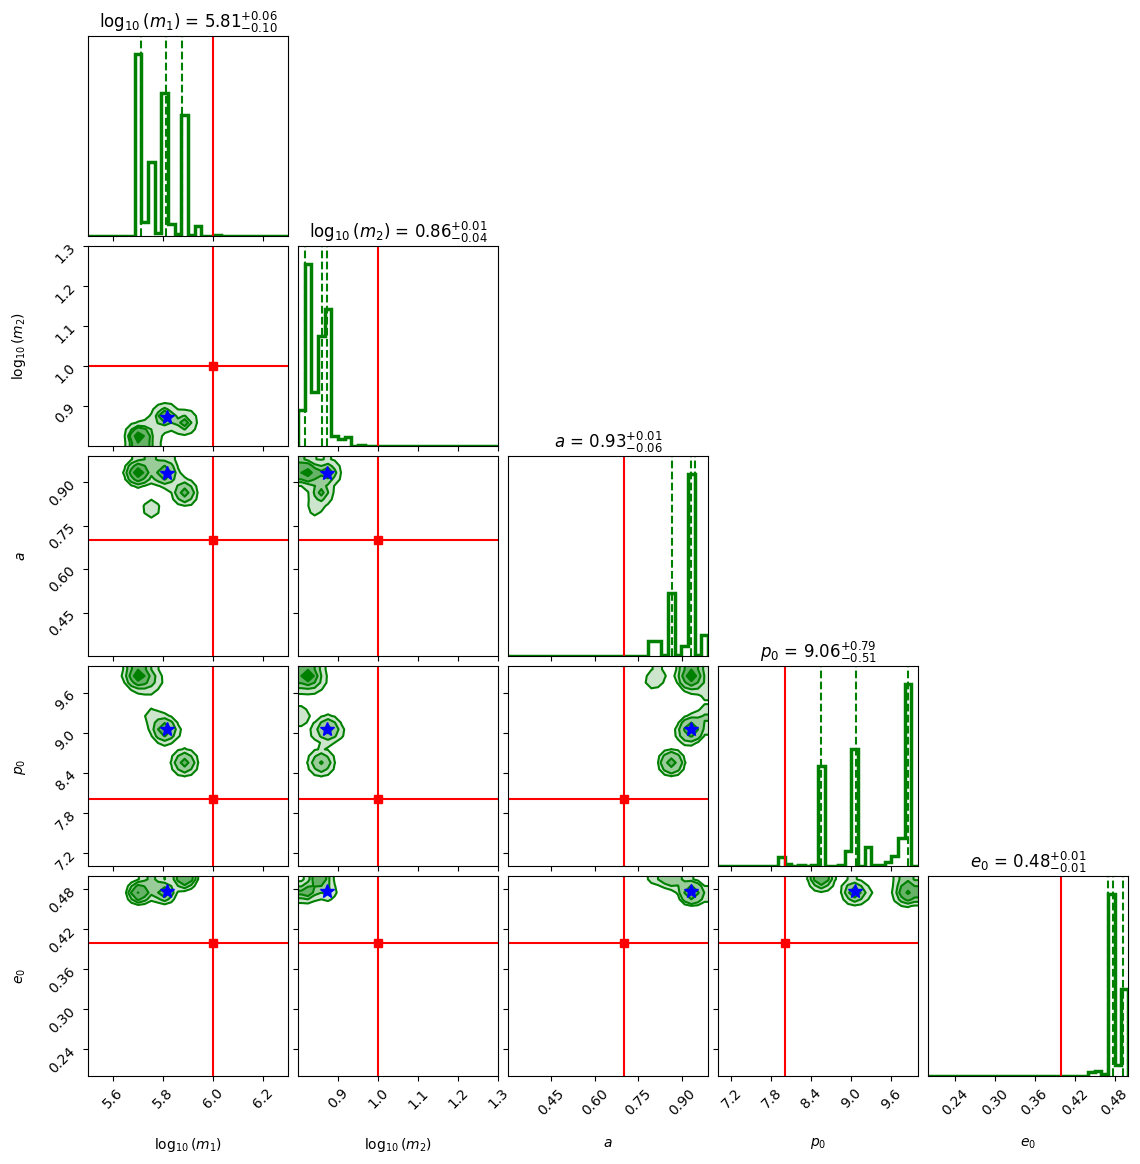

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [19]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 4.8  (0.00% of N=100000)


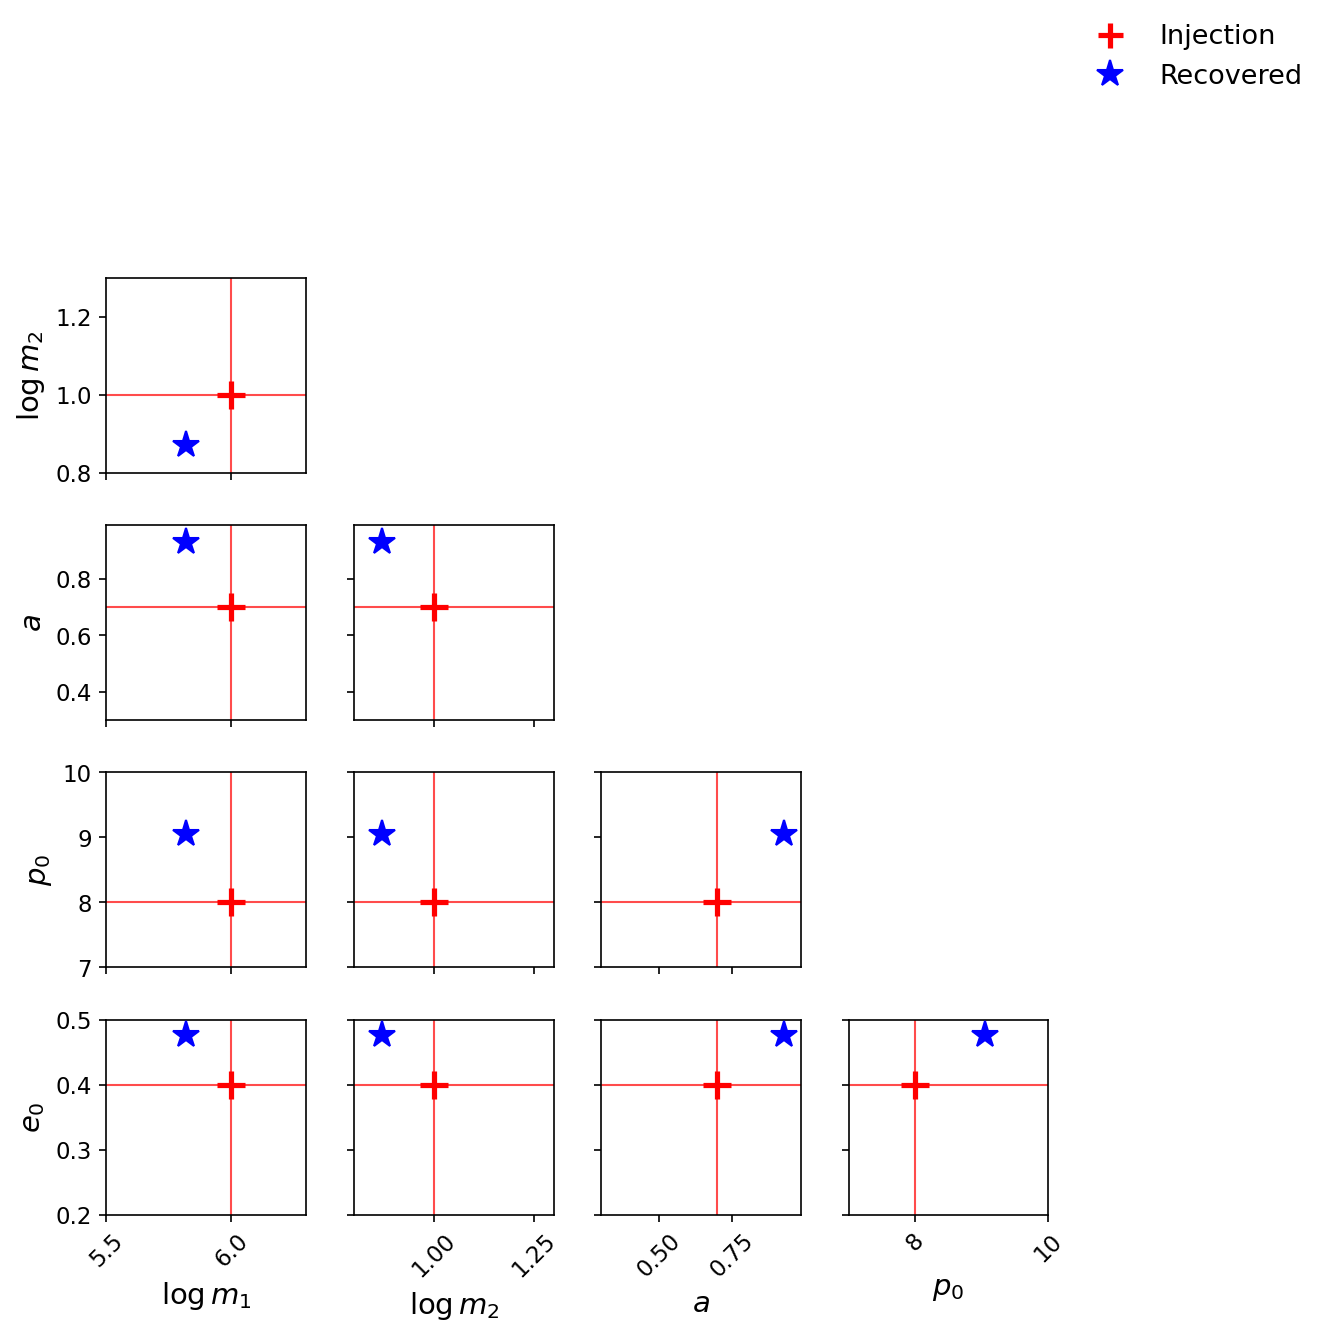

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

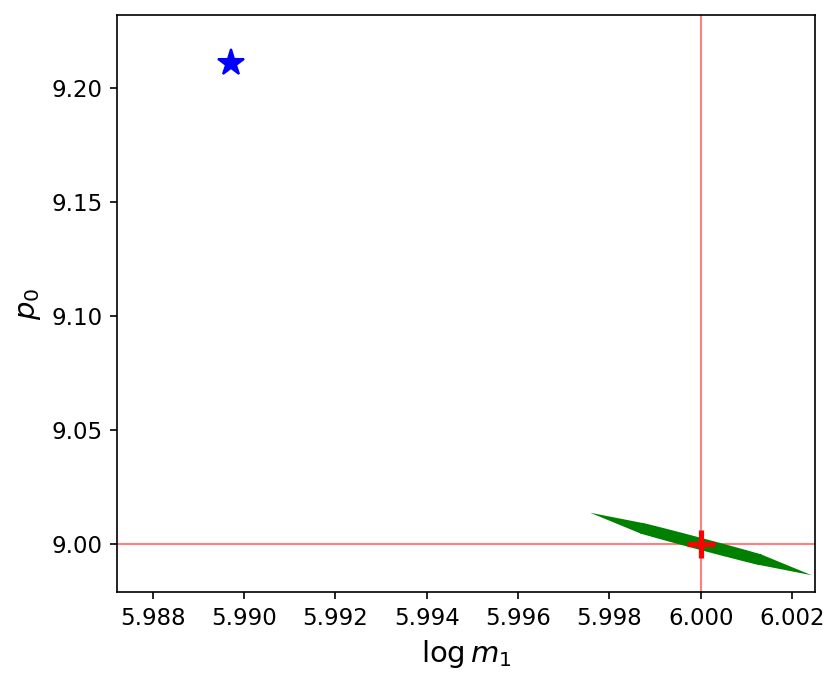

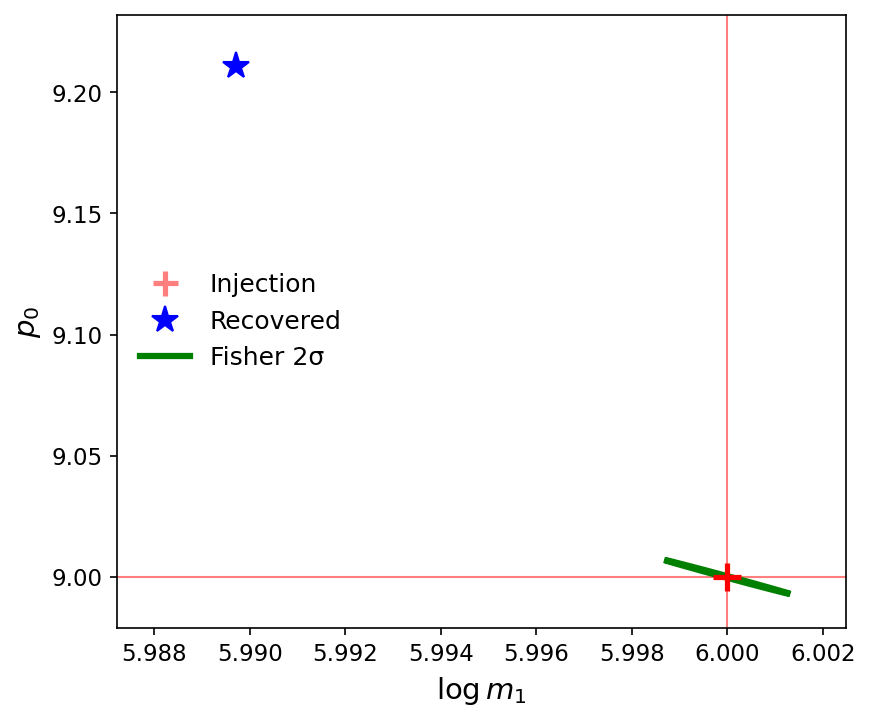

In [ ]:
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.patches import Ellipse

# with open('/home/svu/e1498138/emri_search/work/cov_matrix_noise_1yr.pkl', 'rb') as f:
#     cov = pickle.load(f)

# def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
#     vals, vecs = np.linalg.eigh(cov2d)
#     order = vals.argsort()[::-1]
#     vals, vecs = vals[order], vecs[:, order]
#     angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
#     ell = Ellipse(xy=(cx, cy),
#                 width=2 * n_sigma * np.sqrt(vals[0]),
#                 height=2 * n_sigma * np.sqrt(vals[1]),
#                 angle=angle, **kwargs)
#     ax.add_patch(ell)

# _pt  = np.asarray(param_true).ravel()
# _map = np.asarray(maxld_pt1).ravel()
# sigs = np.sqrt(np.diag(cov))

# j, i = 0, 3   # x = log10(m1), y = p0
# cov2d = cov[np.ix_([j, i], [j, i])]

# xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
# ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
# xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
# ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.set_xlim(xlo - xpad, xhi + xpad)
# ax.set_ylim(ylo - ypad, yhi + ypad)

# ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
# ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

# draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
#                 n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

# ax.set_xlabel(r'$\log m_1$')
# ax.set_ylabel(r'$p_0$')
# sigs = np.sqrt(np.diag(cov))

# j, i = 0, 3   # x = log10(m1), y = p0
# cov2d = cov[np.ix_([j, i], [j, i])]
# a
# xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
# ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
# xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
# ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.set_xlim(xlo - xpad, xhi + xpad)
# ax.set_ylim(ylo - ypad, yhi + ypad)

# ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
# ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

# draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
#                 n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

# ax.set_xlabel(r'$\log  m_1$')
# ax.set_ylabel(r'$p_0$')

# legend_handles = [
#     Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
#     Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
#     Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
# ]
# ax.legend(handles=legend_handles, frameon=False, fontsize=12)
# plt.tight_layout()
# plt.show()

# connection plot

In [21]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1,-1)
proc1_maxld_pt

array([[5.81762742, 0.87172917, 0.92974298, 9.04845282, 0.47697003]])

In [23]:
# --- Build the ellipsoid the same way old/precompute_lhs_paris3.py does, and test if truth is inside ---
N_SIGMA_PRIOR = 15.0   # old/precompute_lhs_paris3.py uses 3.0 (the _noise version uses 6.0)

_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

sigma_diag = np.sqrt(np.diag(cov_posterior))
ellipse_lo = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)

print(f"{N_SIGMA_PRIOR:.0f}-sigma bounding box (axis-aligned, clipped to prior) vs. truth:")
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for i, name in enumerate(param_names):
    inside = ellipse_lo[i] <= true_pt[i] <= ellipse_hi[i]
    print(f"  {name:>6}: [{ellipse_lo[i]:.5f}, {ellipse_hi[i]:.5f}]   truth={true_pt[i]:.5f}   "
        f"{'inside' if inside else 'OUTSIDE'}")

box_inside = np.all((ellipse_lo <= true_pt) & (true_pt <= ellipse_hi))
print(f"\nTruth inside {N_SIGMA_PRIOR:.0f}-sigma bounding box (all dims)?     {box_inside}")

# the *actual* ellipsoid used for LHS sampling is r <= N_SIGMA_PRIOR in Mahalanobis units
ellipsoid_inside = maha <= N_SIGMA_PRIOR
print(f"Truth inside {N_SIGMA_PRIOR:.0f}-sigma covariance ellipsoid (maha={maha:.1f} <= {N_SIGMA_PRIOR:.0f})?  {ellipsoid_inside}")

15-sigma bounding box (axis-aligned, clipped to prior) vs. truth:
   logm1: [5.60000, 6.40000]   truth=6.00000   inside
   logm2: [1.30000, 1.30000]   truth=1.00000   OUTSIDE
       a: [0.99000, 0.99000]   truth=0.70000   OUTSIDE
      p0: [8.00000, 11.00000]   truth=8.00000   inside
      e0: [0.50000, 0.50000]   truth=0.40000   OUTSIDE

Truth inside 15-sigma bounding box (all dims)?     False
Truth inside 15-sigma covariance ellipsoid (maha=2044.6 <= 15)?  False


In [24]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0]
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [25]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [26]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [27]:
logden_theory_proc1

array([49.75732882, 46.96361768, 44.99871696, 47.11350569, 44.66756855,
       45.93792678, 46.27796482, 46.09264868, 46.37524674, 45.88286368,
       45.23188526, 44.99847988, 44.76717081, 44.38506478, 44.07188098,
       46.16441887, 44.40878401, 43.89380916, 45.70920784, 46.14367436,
       44.7701836 , 46.37757099, 43.42407391, 43.65027846, 43.76529649,
       44.39474415, 44.74765429, 44.55237394, 44.45243819, 45.6029922 ,
       45.57897552, 44.96033977, 43.84992932, 45.78980008, 44.09431066,
       43.33586515, 44.49446633, 45.21516075, 43.81878203, 43.16277846,
       44.71040995, 44.1901174 , 44.71349934, 44.87302108, 45.77926376,
       46.10747223, 45.07650374, 43.83361955, 45.22497772, 62.32136975])

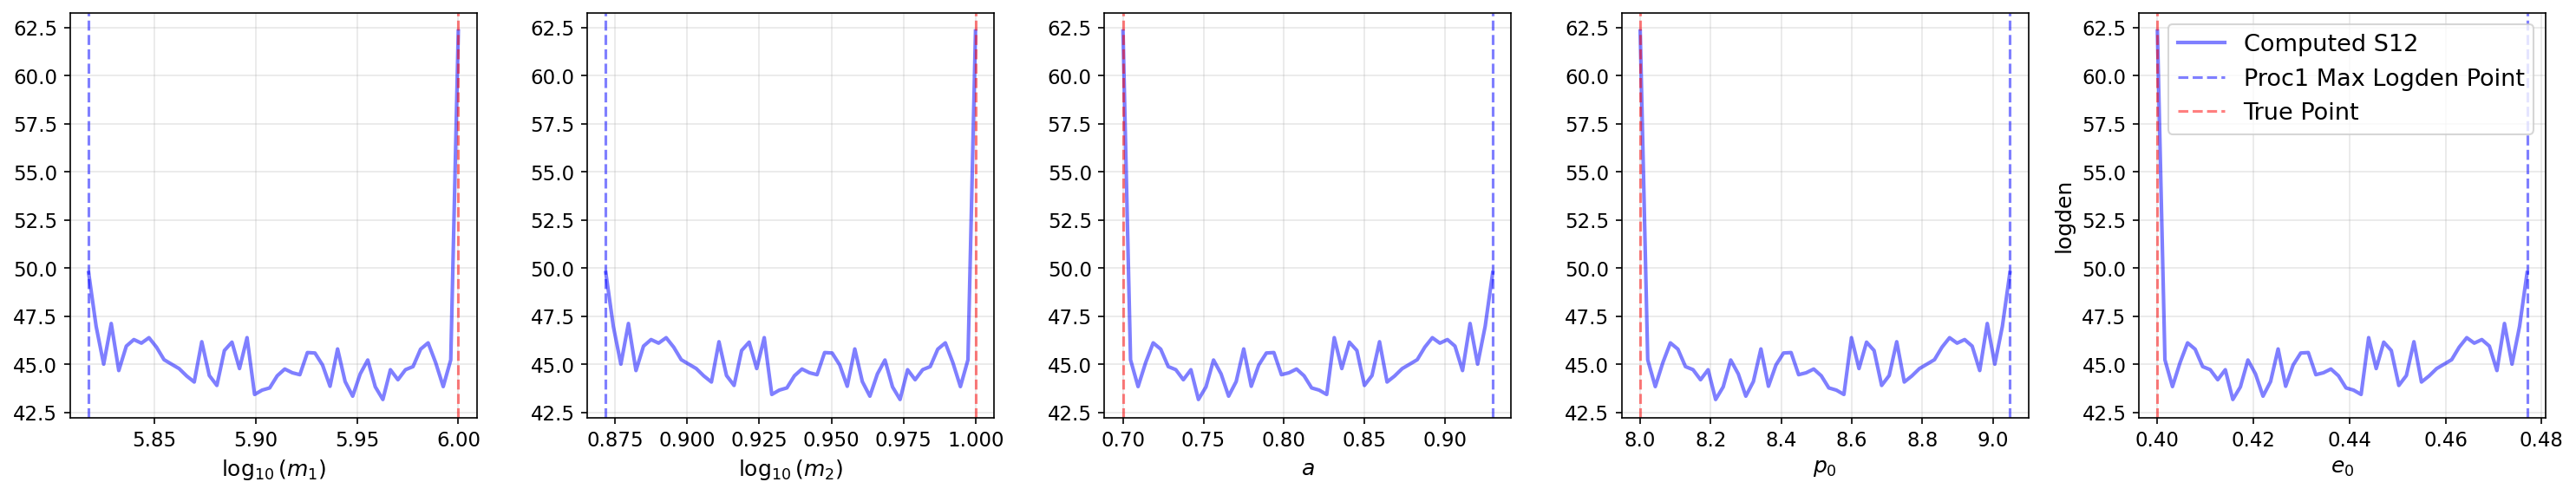

In [28]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [24]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [25]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [26]:
logden_tm = log_density(line_points_logm1.T)


In [28]:
logden_tm

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,      

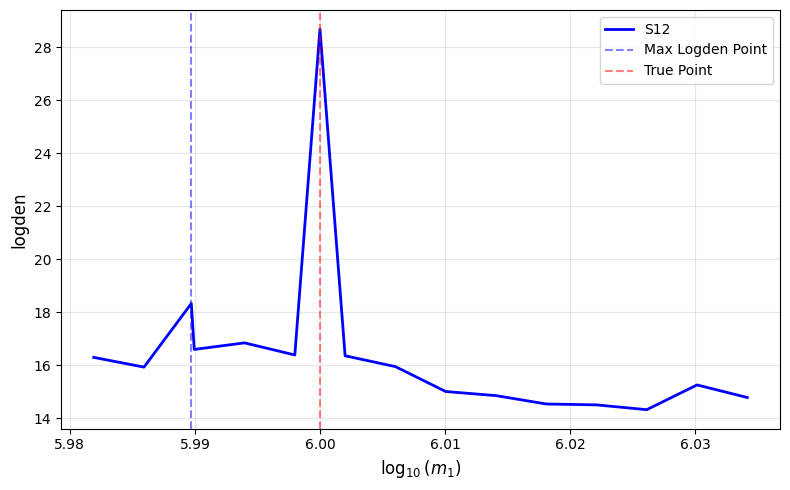

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()